# hw2: Решающие деревья

*Спасибо великому курсу великого Евгения Соколова*

### О задании

Задание состоит из двух разделов:
1. В первом разделе вы научитесь применять деревья из sklearn для задачи классификации. Вы посмотрите какие разделяющие поверхности деревья строят для различных датасетов и проанализируете их зависимость от различных гиперпараметров.
2. Во втором разделе вы попробуете реализовать свое решающее дерево и сравните его со стандартное имплементацией из sklearn. Вы также протестируете деревья на более сложных датасетах и сравните различные подходы к кодированию категориальных признаков.

Все данные, на которых будут обучаться модели, вы можете найти на диске.

### Оценивание и штрафы
Каждая из задач имеет определенную «стоимость» (указана в скобках около задачи). Максимально допустимая оценка за работу — 10 баллов. Неэффективная и/или неоригинальная реализация кода может негативно отразиться на оценке.

### Формат сдачи
Заполненный ноутбук ```hw2-trees.ipynb``` и модуль с реализованными функциями и классами ```hw2code.py``` необходимо загрузить на свой Github. Затем нужно оставить комментарий в Google-таблице с оценками в столбце <<hw2>> в строке со своей фамилией о том, что вы выполнили работу с указанием ника на Kaggle. 

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from matplotlib.colors import Colormap, ListedColormap
import pandas as pd
from sklearn.model_selection import train_test_split
import seaborn as sns
sns.set(style='whitegrid')

import warnings
warnings.filterwarnings('ignore')

# 1. Решающие деревья. Визуализация.

В этой части мы рассмотрим два простых двумерных датасета сделанных с помощью `make_moons`, `make_circles` и посмотрим как ведет себя разделяющая поверхность в зависимости от различных гиперпараметров.

In [13]:
from sklearn.datasets import make_moons, make_circles, make_classification
datasets = [
    make_circles(noise=0.2, factor=0.5, random_state=42),
    make_moons(noise=0.2, random_state=42),
    make_classification(n_classes=3, n_clusters_per_class=1, n_features=2, class_sep=.8, random_state=3,
                        n_redundant=0, )
]

In [14]:
palette = sns.color_palette(n_colors=3)
cmap = ListedColormap(palette)

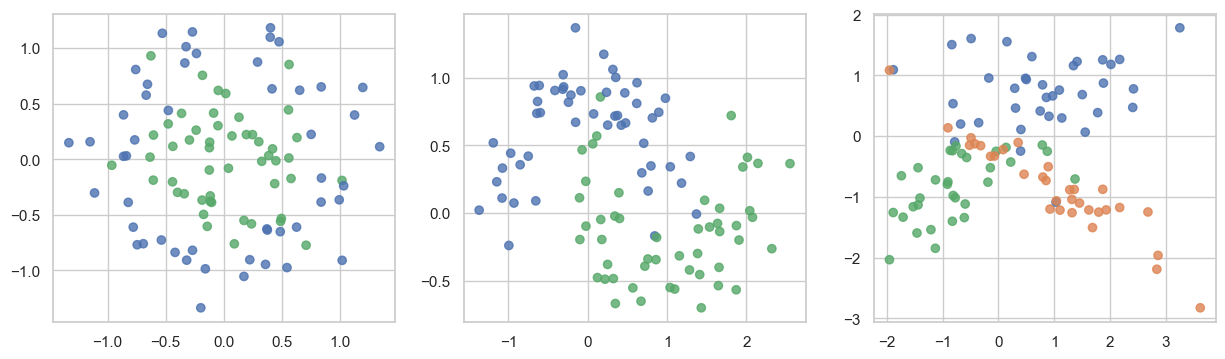

In [15]:
plt.figure(figsize=(15, 4))
for i, (x, y) in enumerate(datasets):
    plt.subplot(1, 3, i + 1)
    plt.scatter(x[:, 0], x[:, 1], c=y, cmap=cmap, alpha=.8)

__Задание 1. (1 балл)__

Для каждого датасета обучите решающее дерево с параметрами по умолчанию, предварительно разбив выборку на обучающую и тестовую. Постройте разделящие поверхности (для этого воспользуйтесь функцией `plot_surface`, пример ниже). Посчитайте accuracy на обучающей и тестовой выборках. Сильно ли деревья переобучились?

In [16]:
def plot_surface(clf, X, y):
    plot_step = 0.01
    palette = sns.color_palette(n_colors=len(np.unique(y)))
    cmap = ListedColormap(palette)
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step),
                         np.arange(y_min, y_max, plot_step))
    plt.tight_layout(h_pad=0.5, w_pad=0.5, pad=2.5)

    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    cs = plt.contourf(xx, yy, Z, cmap=cmap, alpha=0.3)

    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap, alpha=.7,
                edgecolors=np.array(palette)[y], linewidths=2)

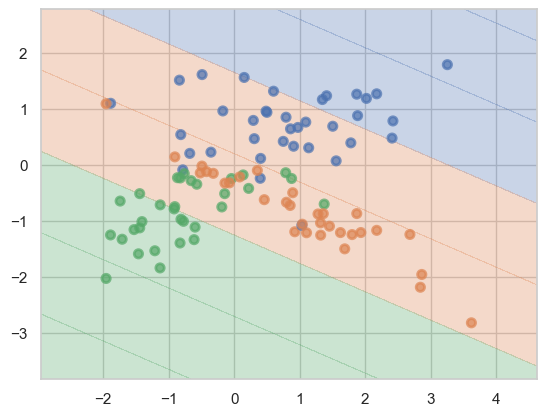

In [17]:
# Пример:
from sklearn.linear_model import LinearRegression
X, y = datasets[2]
lr  = LinearRegression().fit(X, y)
plot_surface(lr, X, y)

Кружочки        | Обучающая точность: 1.000 | Тестовая точность: 0.640 | Разница: 0.360
Лунушки         | Обучающая точность: 1.000 | Тестовая точность: 0.920 | Разница: 0.080
Классификация   | Обучающая точность: 1.000 | Тестовая точность: 0.800 | Разница: 0.200


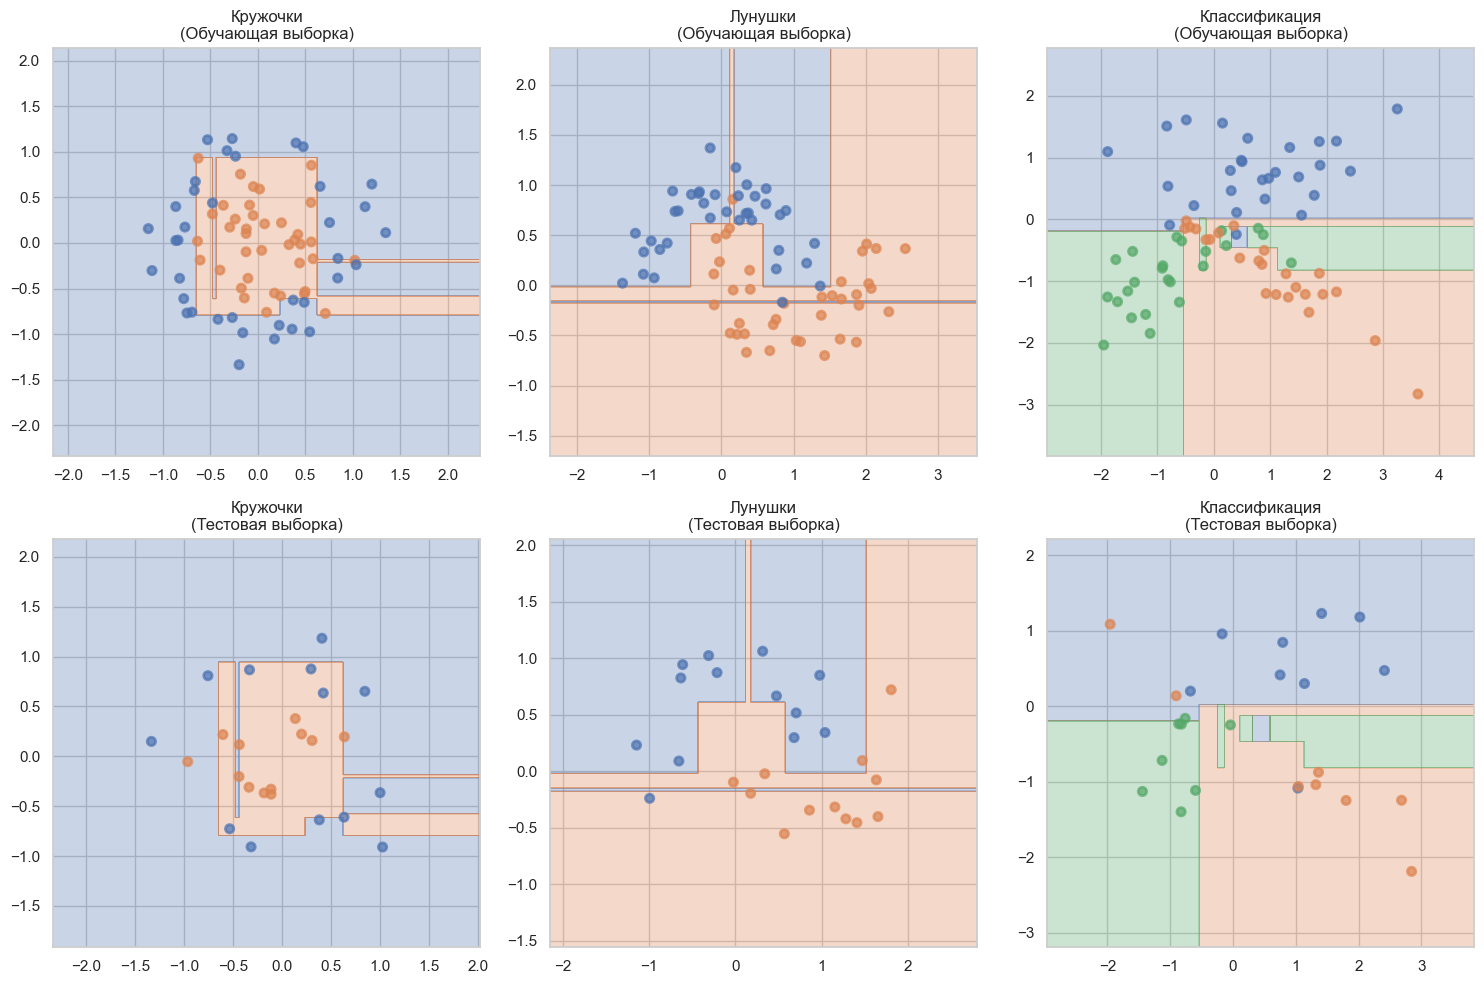

In [18]:
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import mean_squared_error, accuracy_score

datasets = [
    ("Кружочки", make_circles(noise=0.2, factor=0.5, random_state=42)),
    ("Лунушки", make_moons(noise=0.2, random_state=42)),
    ("Классификация", make_classification(
        n_classes=3,
        n_clusters_per_class=1,
        n_features=2,
        class_sep=0.8,
        random_state=3,
        n_redundant=0
    ))
]

dtc = DecisionTreeClassifier(random_state=42)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for i, (name, (X, y)) in enumerate(datasets):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=43)
    dtc.fit(X_train, y_train)
    
    pred_train = dtc.predict(X_train)
    pred_test = dtc.predict(X_test)
    
    acc_train, acc_test = accuracy_score(y_train, pred_train), accuracy_score(y_test, pred_test)
    print(f'{name:15} | Обучающая точность: {acc_train:.3f} | '
          f'Тестовая точность: {acc_test:.3f} | '
          f'Разница: {abs(acc_train - acc_test):.3f}')

    for row, (X, y) in enumerate([(X_train, y_train), (X_test, y_test)]):
        current_ax = axes[row, i]
        plt.sca(current_ax)
        plot_surface(dtc, X, y)
        current_ax.set_title(f"{name}\n({'Обучающая' if row == 0 else 'Тестовая'} выборка)")

plt.tight_layout()
plt.show()

__Ответ:__ Да, дерево переобучилось. acc_train = 1, а acc_test -> 1 (хоть и не достигает её и зависит от количества выборочных данных)

__Задание 2. (1.5 балла)__

Попробуйте перебрать несколько параметров для регуляризации (напр. `max_depth`, `min_samples_leaf`). Для каждого набора гиперпараметров постройте разделяющую поверхность, выведите обучающую и тестовую ошибки. Можно делать кросс-валидацию или просто разбиение на трейн и тест, главное делайте каждый раз одинаковое разбиение, чтобы можно было корректно сравнивать (помните же, что итоговое дерево сильно зависит от небольшого изменения обучающей выборки?). Проследите как меняется разделяющая поверхность и обобщающая способность. Почему так происходит, одинаково ли изменение для разных датасетов?


ДАТАСЕТ: КРУЖОЧКИ

--- min_samples_leaf = 1 ---
max_depth= 1 | Train: 0.660 | Test: 0.600 | DELTA: +0.060
max_depth= 2 | Train: 0.780 | Test: 0.680 | DELTA: +0.100
max_depth= 3 | Train: 0.900 | Test: 0.720 | DELTA: +0.180
max_depth= 5 | Train: 0.980 | Test: 0.820 | DELTA: +0.160
max_depth= 7 | Train: 1.000 | Test: 0.800 | DELTA: +0.200
max_depth=11 | Train: 1.000 | Test: 0.800 | DELTA: +0.200


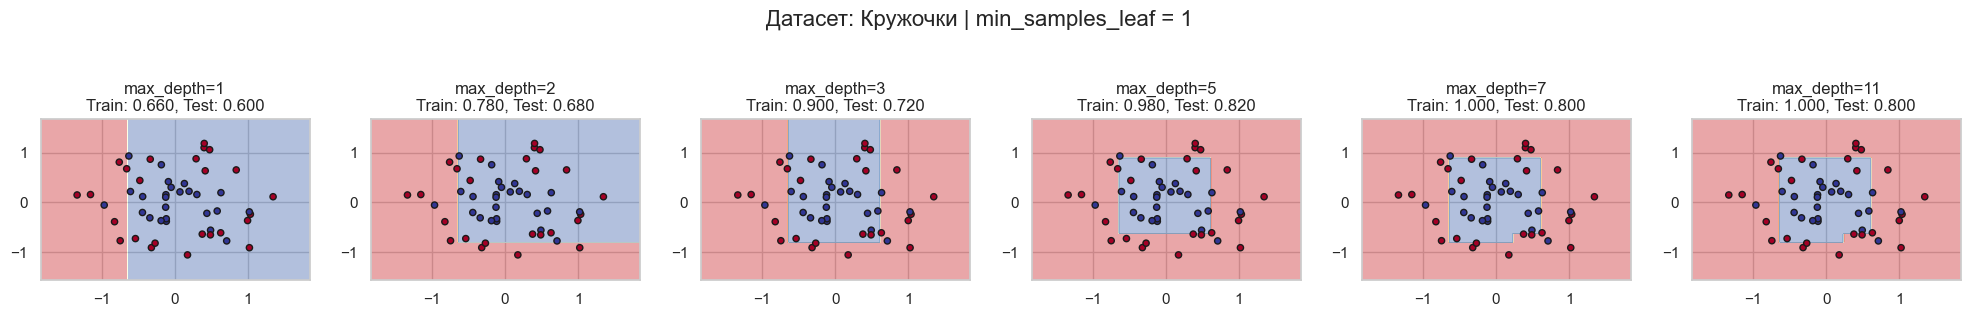


--- min_samples_leaf = 2 ---
max_depth= 1 | Train: 0.660 | Test: 0.600 | DELTA: +0.060
max_depth= 2 | Train: 0.780 | Test: 0.680 | DELTA: +0.100
max_depth= 3 | Train: 0.900 | Test: 0.720 | DELTA: +0.180
max_depth= 5 | Train: 0.980 | Test: 0.820 | DELTA: +0.160
max_depth= 7 | Train: 0.980 | Test: 0.820 | DELTA: +0.160
max_depth=11 | Train: 0.980 | Test: 0.820 | DELTA: +0.160


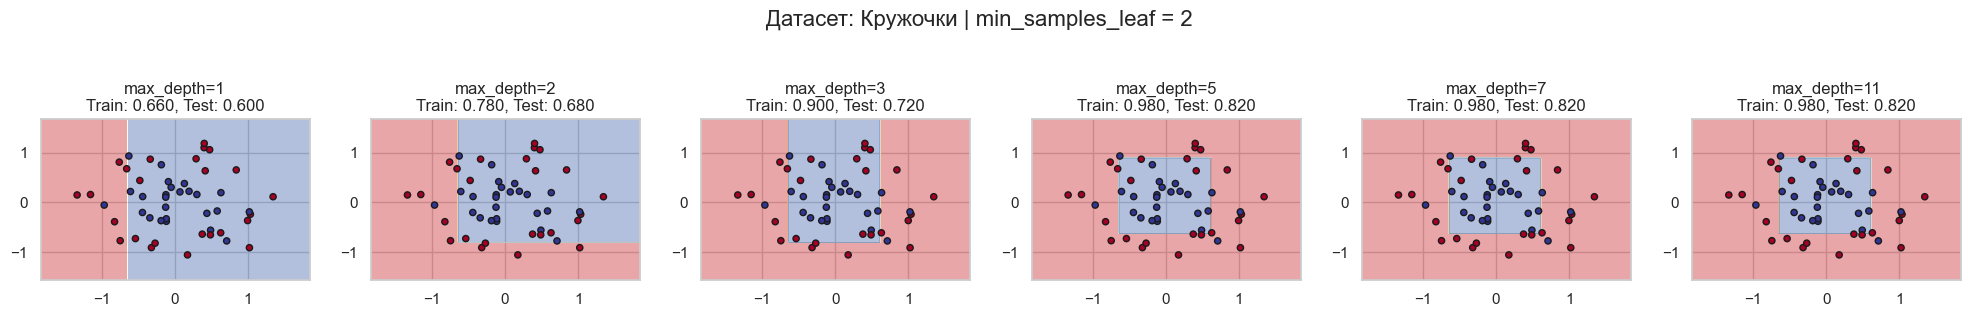


--- min_samples_leaf = 3 ---
max_depth= 1 | Train: 0.660 | Test: 0.600 | DELTA: +0.060
max_depth= 2 | Train: 0.780 | Test: 0.680 | DELTA: +0.100
max_depth= 3 | Train: 0.900 | Test: 0.720 | DELTA: +0.180
max_depth= 5 | Train: 0.980 | Test: 0.760 | DELTA: +0.220
max_depth= 7 | Train: 0.980 | Test: 0.760 | DELTA: +0.220
max_depth=11 | Train: 0.980 | Test: 0.760 | DELTA: +0.220


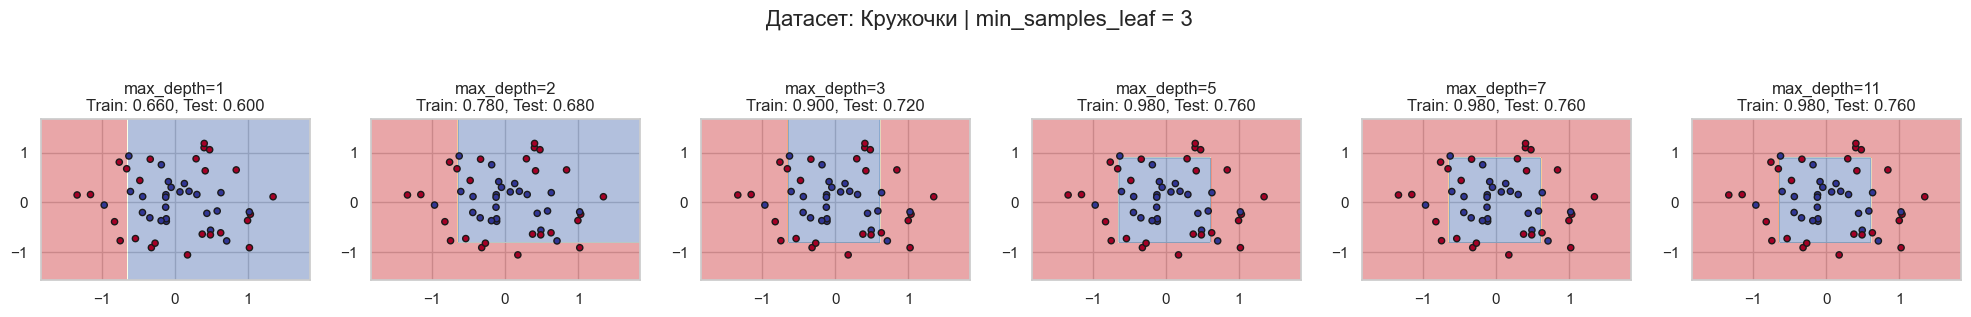


--- min_samples_leaf = 5 ---
max_depth= 1 | Train: 0.660 | Test: 0.600 | DELTA: +0.060
max_depth= 2 | Train: 0.780 | Test: 0.680 | DELTA: +0.100
max_depth= 3 | Train: 0.900 | Test: 0.720 | DELTA: +0.180
max_depth= 5 | Train: 0.960 | Test: 0.780 | DELTA: +0.180
max_depth= 7 | Train: 0.960 | Test: 0.780 | DELTA: +0.180
max_depth=11 | Train: 0.960 | Test: 0.780 | DELTA: +0.180


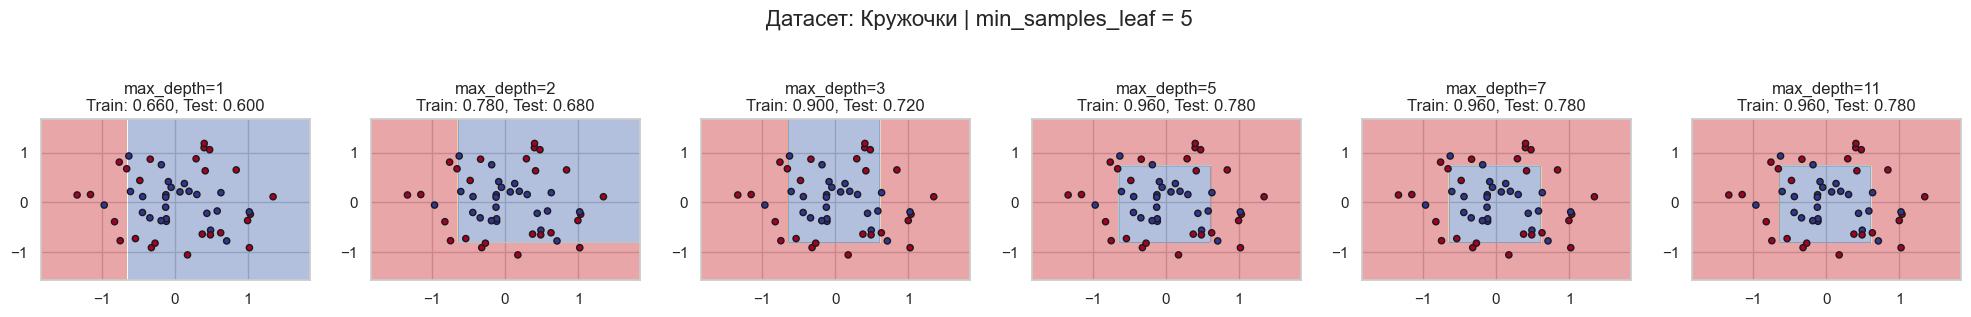


--- min_samples_leaf = 7 ---
max_depth= 1 | Train: 0.660 | Test: 0.600 | DELTA: +0.060
max_depth= 2 | Train: 0.780 | Test: 0.720 | DELTA: +0.060
max_depth= 3 | Train: 0.880 | Test: 0.820 | DELTA: +0.060
max_depth= 5 | Train: 0.900 | Test: 0.820 | DELTA: +0.080
max_depth= 7 | Train: 0.900 | Test: 0.820 | DELTA: +0.080
max_depth=11 | Train: 0.900 | Test: 0.820 | DELTA: +0.080


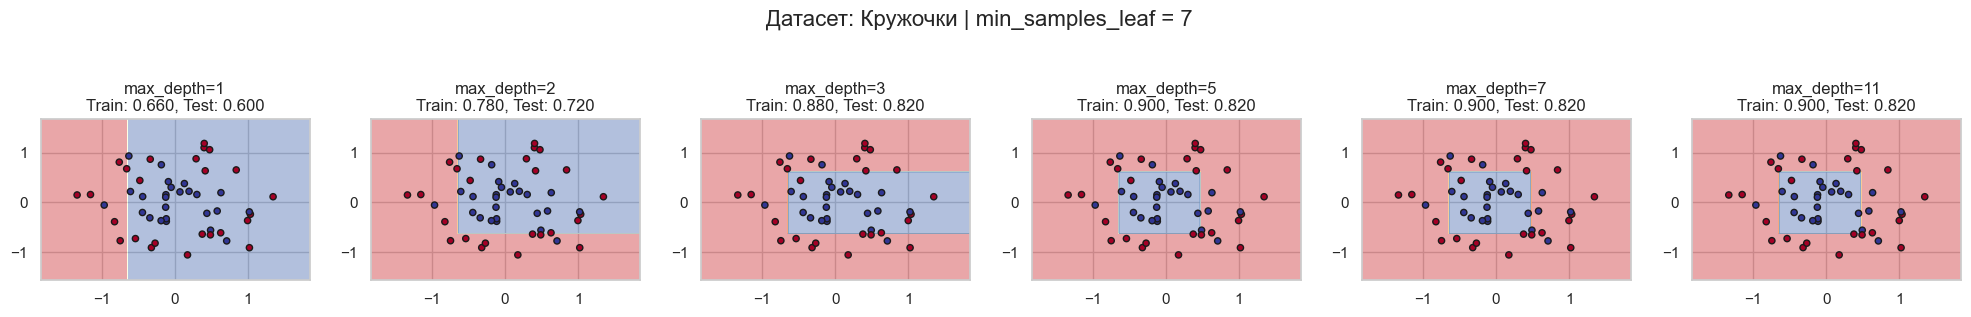


--- min_samples_leaf = 11 ---
max_depth= 1 | Train: 0.640 | Test: 0.580 | DELTA: +0.060
max_depth= 2 | Train: 0.700 | Test: 0.680 | DELTA: +0.020
max_depth= 3 | Train: 0.720 | Test: 0.780 | DELTA: -0.060
max_depth= 5 | Train: 0.720 | Test: 0.780 | DELTA: -0.060
max_depth= 7 | Train: 0.720 | Test: 0.780 | DELTA: -0.060
max_depth=11 | Train: 0.720 | Test: 0.780 | DELTA: -0.060


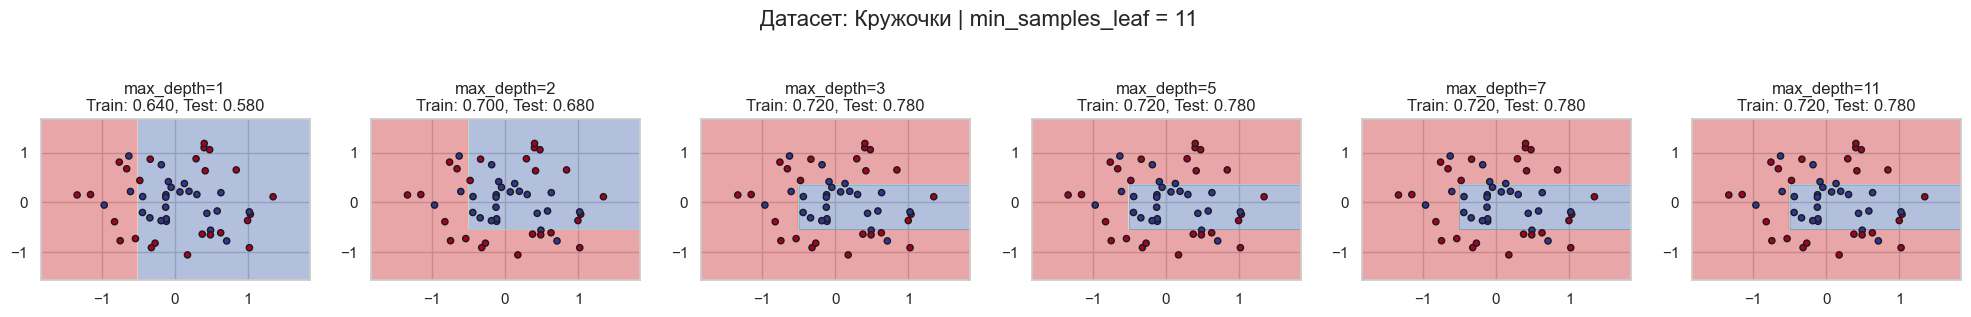


ДАТАСЕТ: ЛУНУШКИ

--- min_samples_leaf = 1 ---
max_depth= 1 | Train: 0.840 | Test: 0.820 | DELTA: +0.020
max_depth= 2 | Train: 0.840 | Test: 0.820 | DELTA: +0.020
max_depth= 3 | Train: 0.980 | Test: 0.780 | DELTA: +0.200
max_depth= 5 | Train: 1.000 | Test: 0.860 | DELTA: +0.140
max_depth= 7 | Train: 1.000 | Test: 0.860 | DELTA: +0.140
max_depth=11 | Train: 1.000 | Test: 0.860 | DELTA: +0.140


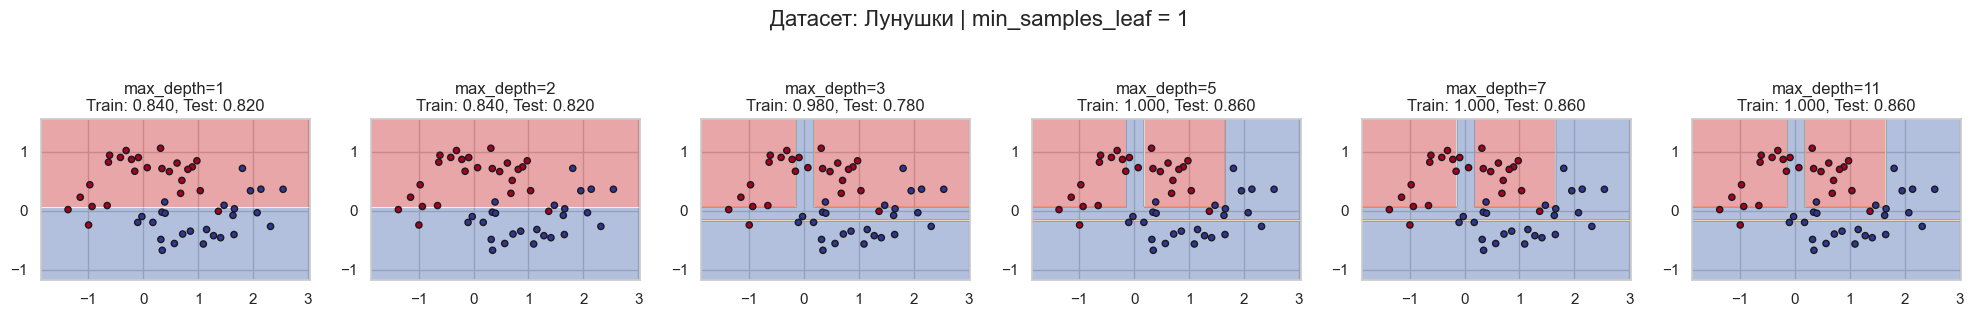


--- min_samples_leaf = 2 ---
max_depth= 1 | Train: 0.840 | Test: 0.820 | DELTA: +0.020
max_depth= 2 | Train: 0.840 | Test: 0.820 | DELTA: +0.020
max_depth= 3 | Train: 0.960 | Test: 0.780 | DELTA: +0.180
max_depth= 5 | Train: 0.960 | Test: 0.780 | DELTA: +0.180
max_depth= 7 | Train: 0.960 | Test: 0.780 | DELTA: +0.180
max_depth=11 | Train: 0.960 | Test: 0.780 | DELTA: +0.180


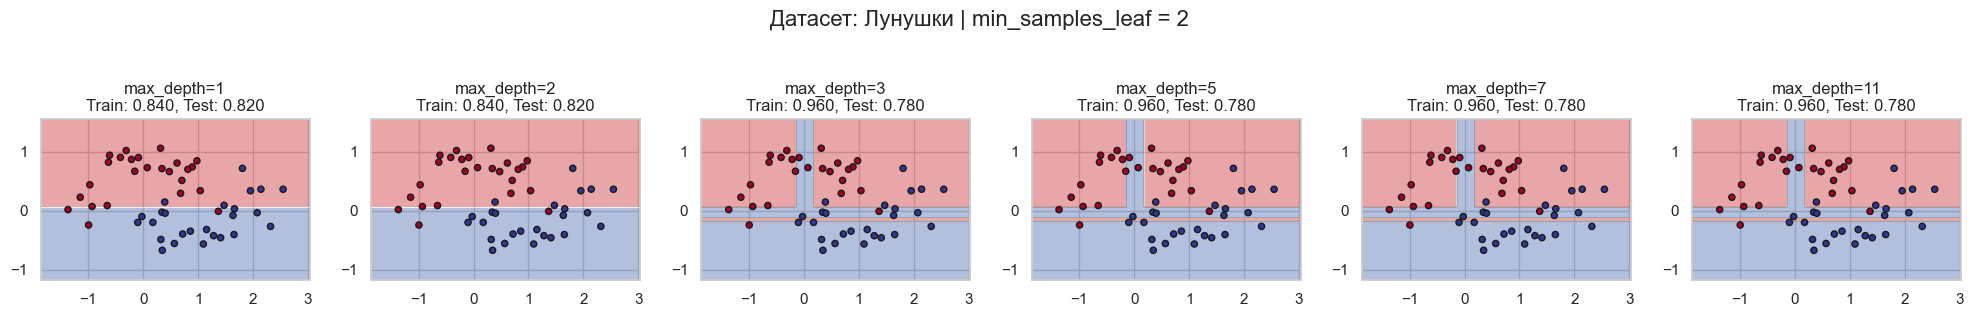


--- min_samples_leaf = 3 ---
max_depth= 1 | Train: 0.840 | Test: 0.820 | DELTA: +0.020
max_depth= 2 | Train: 0.840 | Test: 0.820 | DELTA: +0.020
max_depth= 3 | Train: 0.960 | Test: 0.780 | DELTA: +0.180
max_depth= 5 | Train: 0.960 | Test: 0.780 | DELTA: +0.180
max_depth= 7 | Train: 0.960 | Test: 0.780 | DELTA: +0.180
max_depth=11 | Train: 0.960 | Test: 0.780 | DELTA: +0.180


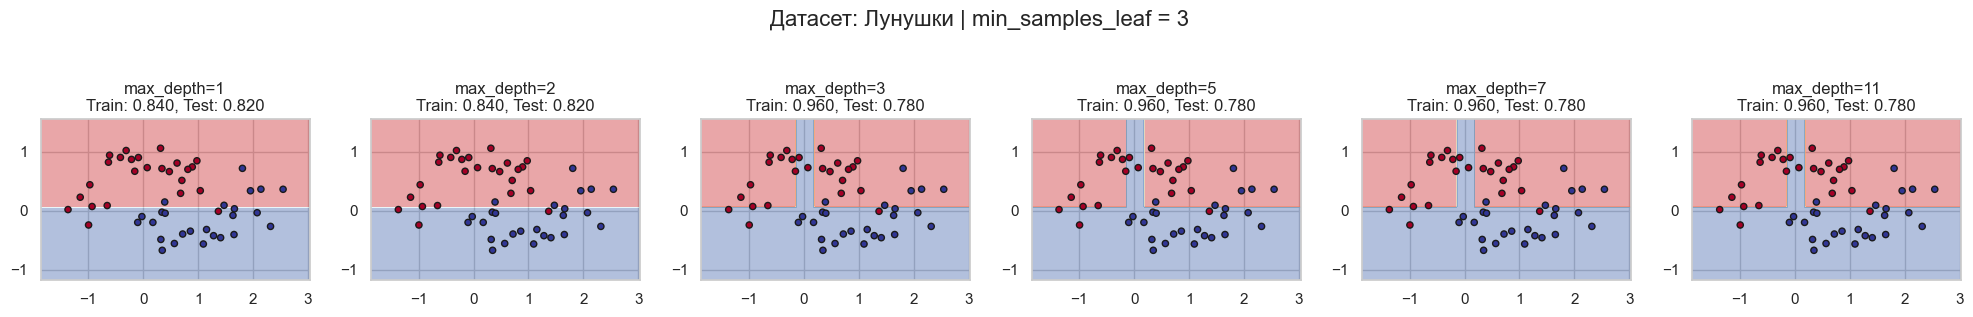


--- min_samples_leaf = 5 ---
max_depth= 1 | Train: 0.840 | Test: 0.820 | DELTA: +0.020
max_depth= 2 | Train: 0.840 | Test: 0.820 | DELTA: +0.020
max_depth= 3 | Train: 0.960 | Test: 0.780 | DELTA: +0.180
max_depth= 5 | Train: 0.960 | Test: 0.780 | DELTA: +0.180
max_depth= 7 | Train: 0.960 | Test: 0.780 | DELTA: +0.180
max_depth=11 | Train: 0.960 | Test: 0.780 | DELTA: +0.180


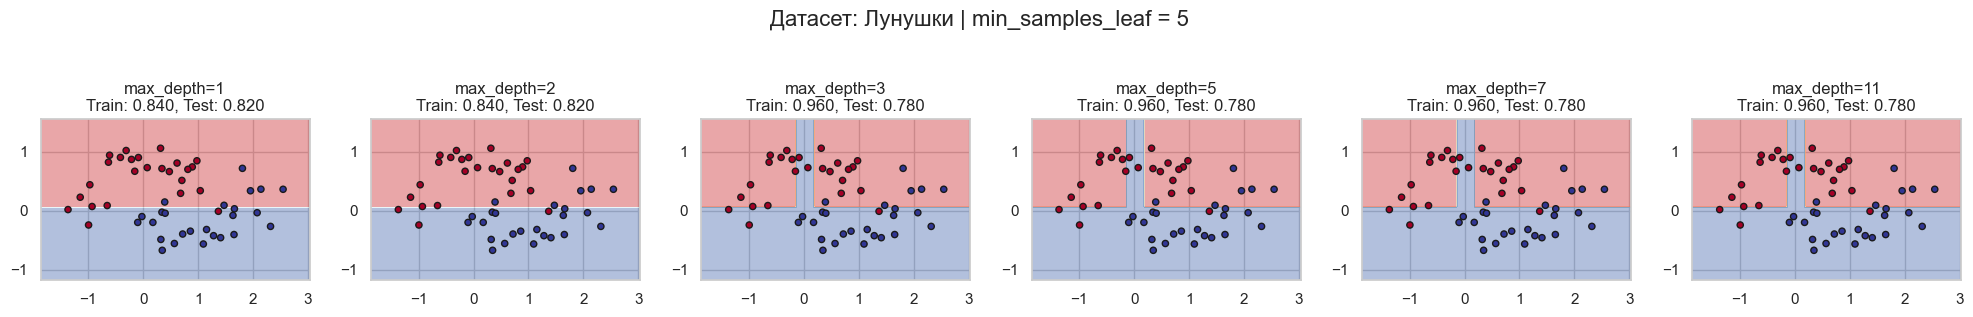


--- min_samples_leaf = 7 ---
max_depth= 1 | Train: 0.840 | Test: 0.820 | DELTA: +0.020
max_depth= 2 | Train: 0.840 | Test: 0.820 | DELTA: +0.020
max_depth= 3 | Train: 0.940 | Test: 0.780 | DELTA: +0.160
max_depth= 5 | Train: 0.940 | Test: 0.780 | DELTA: +0.160
max_depth= 7 | Train: 0.940 | Test: 0.780 | DELTA: +0.160
max_depth=11 | Train: 0.940 | Test: 0.780 | DELTA: +0.160


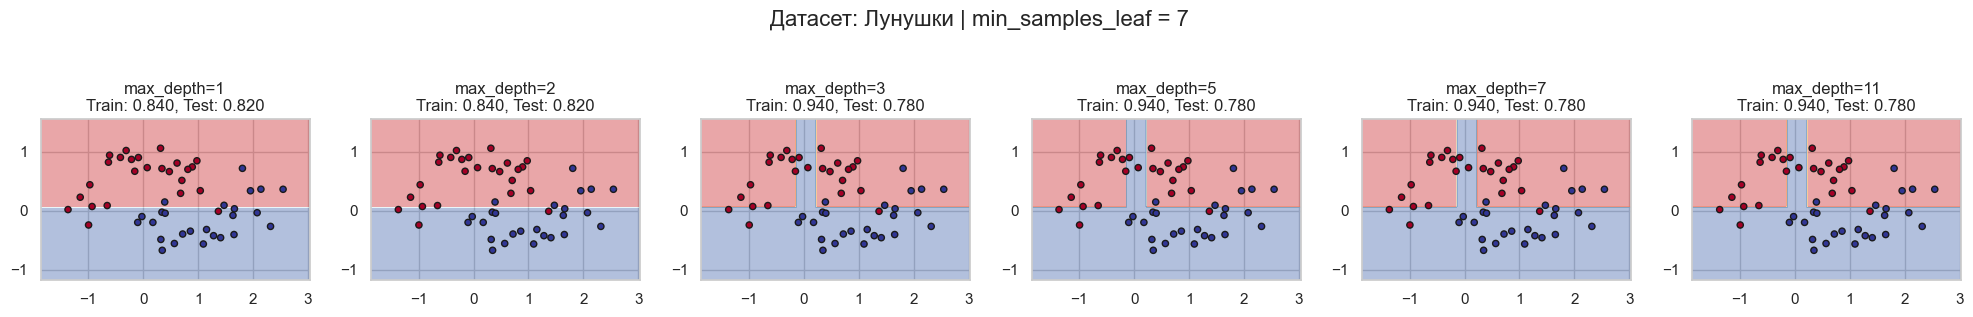


--- min_samples_leaf = 11 ---
max_depth= 1 | Train: 0.840 | Test: 0.820 | DELTA: +0.020
max_depth= 2 | Train: 0.840 | Test: 0.820 | DELTA: +0.020
max_depth= 3 | Train: 0.840 | Test: 0.820 | DELTA: +0.020
max_depth= 5 | Train: 0.840 | Test: 0.820 | DELTA: +0.020
max_depth= 7 | Train: 0.840 | Test: 0.820 | DELTA: +0.020
max_depth=11 | Train: 0.840 | Test: 0.820 | DELTA: +0.020


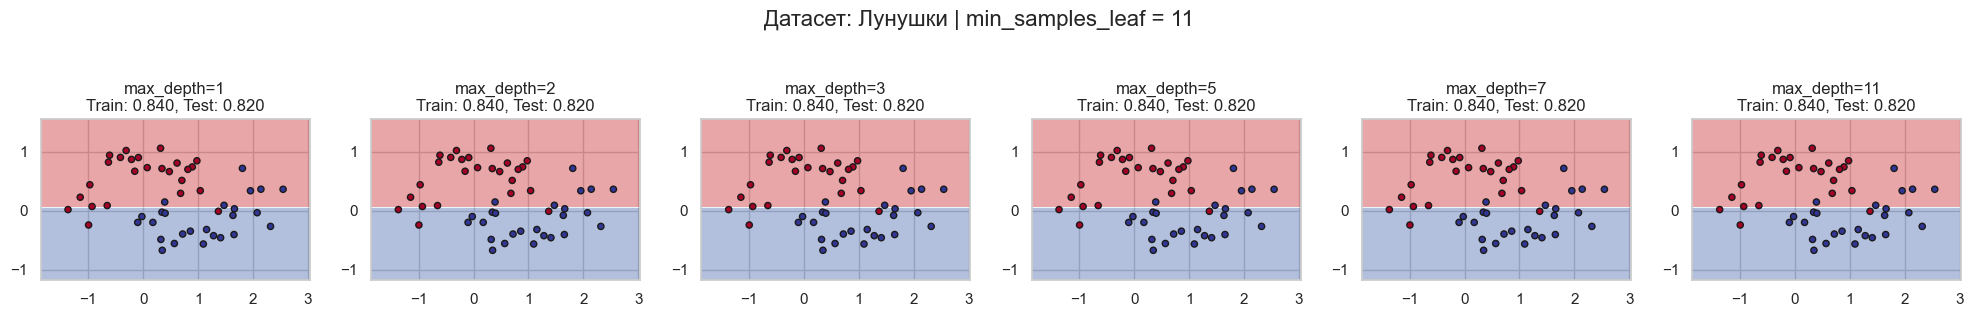


ДАТАСЕТ: КЛАССИФИКАЦИЯ

--- min_samples_leaf = 1 ---
max_depth= 1 | Train: 0.680 | Test: 0.580 | DELTA: +0.100
max_depth= 2 | Train: 0.920 | Test: 0.820 | DELTA: +0.100
max_depth= 3 | Train: 0.920 | Test: 0.820 | DELTA: +0.100
max_depth= 5 | Train: 0.980 | Test: 0.800 | DELTA: +0.180
max_depth= 7 | Train: 1.000 | Test: 0.800 | DELTA: +0.200
max_depth=11 | Train: 1.000 | Test: 0.800 | DELTA: +0.200


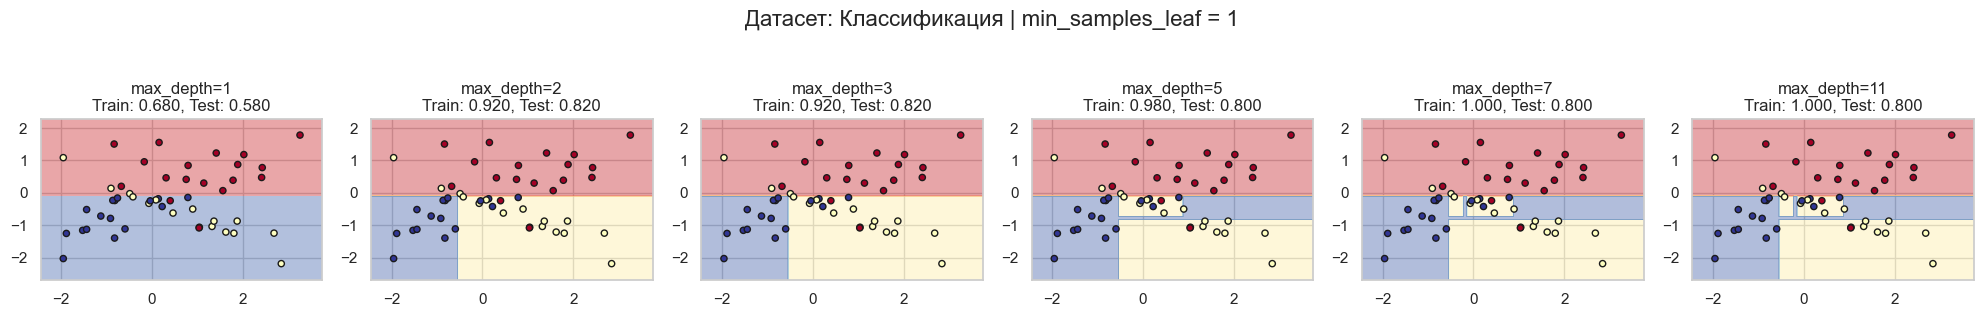


--- min_samples_leaf = 2 ---
max_depth= 1 | Train: 0.680 | Test: 0.580 | DELTA: +0.100
max_depth= 2 | Train: 0.920 | Test: 0.820 | DELTA: +0.100
max_depth= 3 | Train: 0.920 | Test: 0.820 | DELTA: +0.100
max_depth= 5 | Train: 0.960 | Test: 0.800 | DELTA: +0.160
max_depth= 7 | Train: 1.000 | Test: 0.820 | DELTA: +0.180
max_depth=11 | Train: 1.000 | Test: 0.820 | DELTA: +0.180


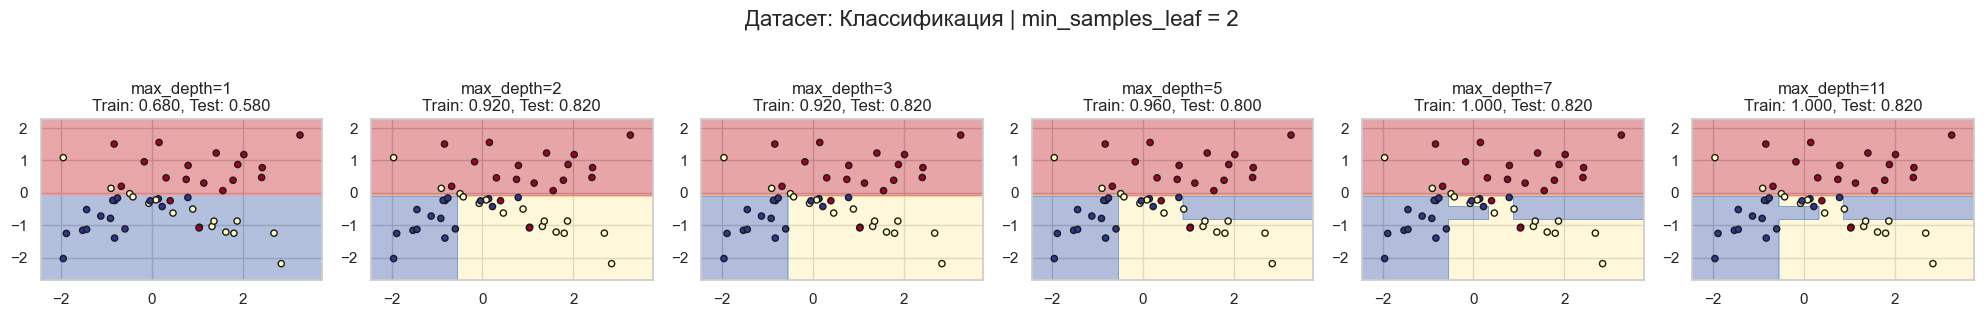


--- min_samples_leaf = 3 ---
max_depth= 1 | Train: 0.680 | Test: 0.580 | DELTA: +0.100
max_depth= 2 | Train: 0.920 | Test: 0.820 | DELTA: +0.100
max_depth= 3 | Train: 0.920 | Test: 0.820 | DELTA: +0.100
max_depth= 5 | Train: 0.940 | Test: 0.820 | DELTA: +0.120
max_depth= 7 | Train: 0.940 | Test: 0.820 | DELTA: +0.120
max_depth=11 | Train: 0.940 | Test: 0.820 | DELTA: +0.120


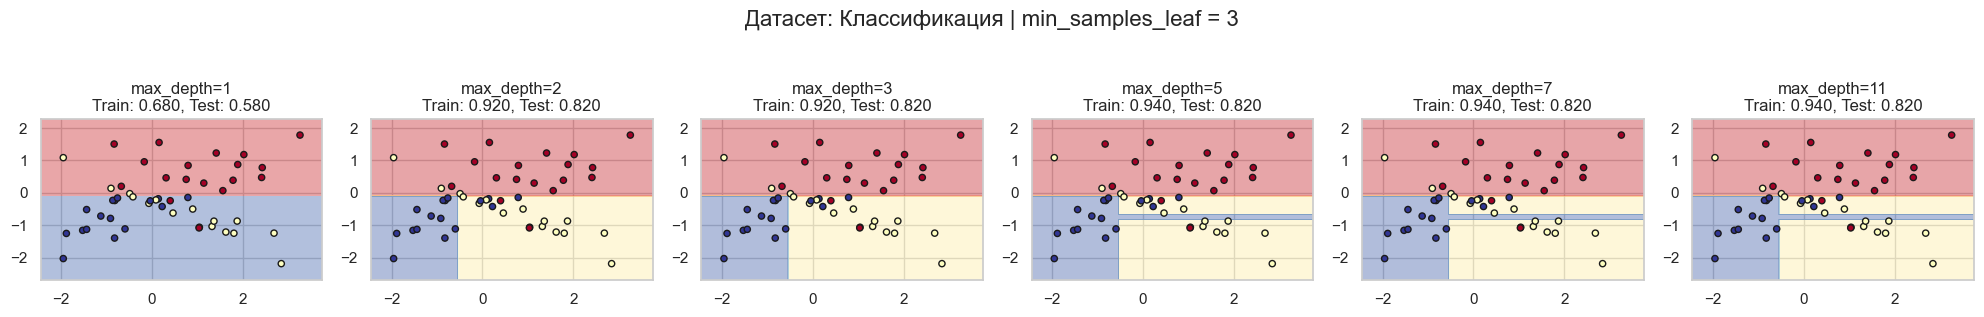


--- min_samples_leaf = 5 ---
max_depth= 1 | Train: 0.680 | Test: 0.580 | DELTA: +0.100
max_depth= 2 | Train: 0.920 | Test: 0.820 | DELTA: +0.100
max_depth= 3 | Train: 0.920 | Test: 0.820 | DELTA: +0.100
max_depth= 5 | Train: 0.940 | Test: 0.800 | DELTA: +0.140
max_depth= 7 | Train: 0.940 | Test: 0.800 | DELTA: +0.140
max_depth=11 | Train: 0.940 | Test: 0.800 | DELTA: +0.140


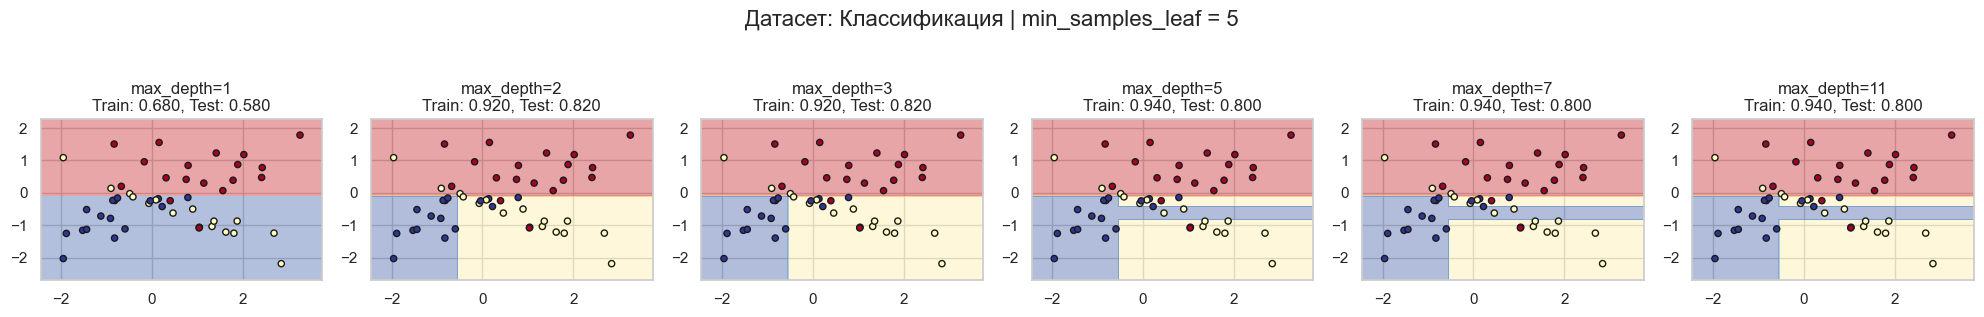


--- min_samples_leaf = 7 ---
max_depth= 1 | Train: 0.680 | Test: 0.580 | DELTA: +0.100
max_depth= 2 | Train: 0.920 | Test: 0.820 | DELTA: +0.100
max_depth= 3 | Train: 0.920 | Test: 0.820 | DELTA: +0.100
max_depth= 5 | Train: 0.920 | Test: 0.820 | DELTA: +0.100
max_depth= 7 | Train: 0.920 | Test: 0.820 | DELTA: +0.100
max_depth=11 | Train: 0.920 | Test: 0.820 | DELTA: +0.100


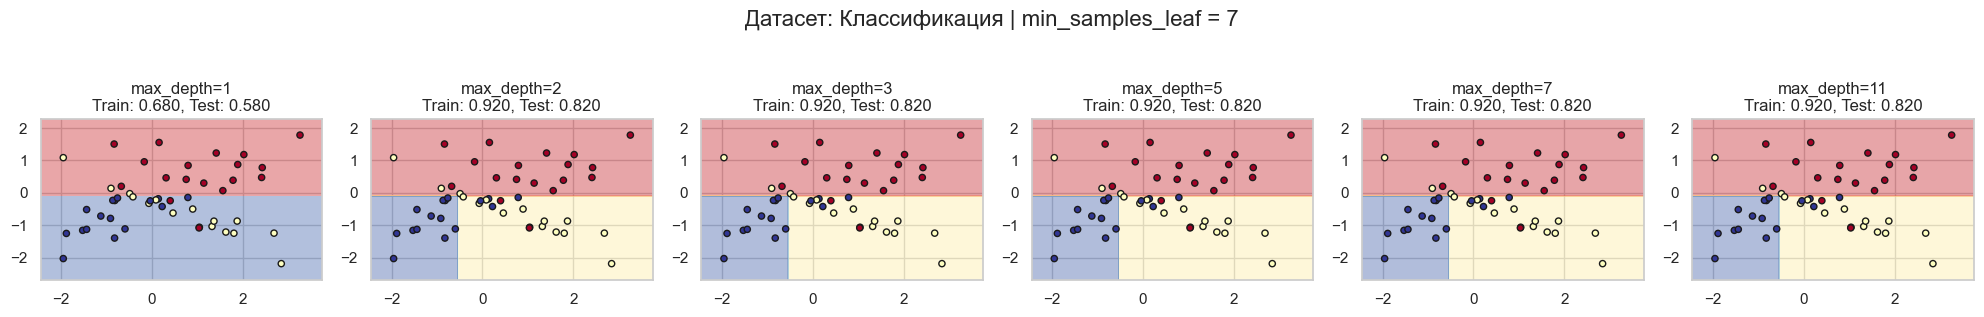


--- min_samples_leaf = 11 ---
max_depth= 1 | Train: 0.680 | Test: 0.580 | DELTA: +0.100
max_depth= 2 | Train: 0.920 | Test: 0.820 | DELTA: +0.100
max_depth= 3 | Train: 0.920 | Test: 0.820 | DELTA: +0.100
max_depth= 5 | Train: 0.920 | Test: 0.820 | DELTA: +0.100
max_depth= 7 | Train: 0.920 | Test: 0.820 | DELTA: +0.100
max_depth=11 | Train: 0.920 | Test: 0.820 | DELTA: +0.100


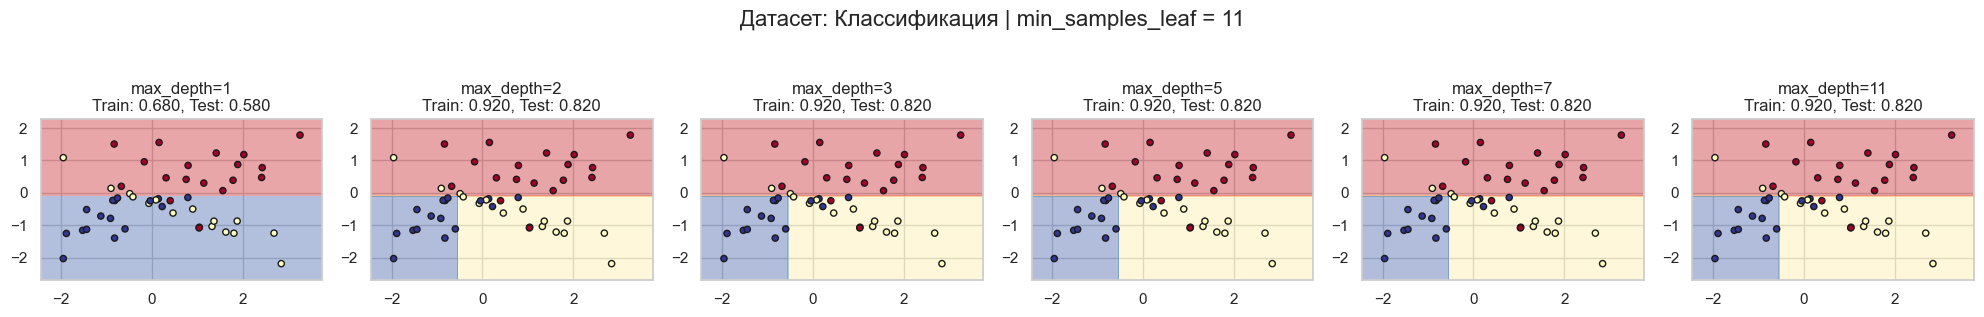

In [19]:
# ### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
params = {
    "max_depth": [1, 2, 3, 5, 7, 11],
    "min_samples_leaf": [1, 2, 3, 5, 7, 11]
}

datasets = [
    ("Кружочки", make_circles(noise=0.2, factor=0.5, random_state=42)),
    ("Лунушки", make_moons(noise=0.2, random_state=42)),
    ("Классификация", make_classification(
        n_classes=3,
        n_clusters_per_class=1,
        n_features=2,
        class_sep=0.8,
        random_state=3,
        n_redundant=0
    ))
]

def plot_surface(clf, X, y):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                        np.arange(y_min, y_max, 0.02))
    
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    plt.contourf(xx, yy, Z, alpha=0.4, cmap=plt.cm.RdYlBu)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=20, edgecolor='k', cmap=plt.cm.RdYlBu)

for i, (name, (X, y)) in enumerate(datasets):
    print(f"\n{'='*60}")
    print(f"ДАТАСЕТ: {name.upper()}")
    print(f"{'='*60}")
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.5, stratify=y, random_state=43
    )
    
    results = []
    
    for leaf_idx, min_samples_leaf in enumerate(params['min_samples_leaf']):
        print(f"\n--- min_samples_leaf = {min_samples_leaf} ---")
        
        plt.figure(figsize=(20, 3))
        plt.suptitle(f"Датасет: {name} | min_samples_leaf = {min_samples_leaf}", 
                     fontsize=16, y=1.05)
        
        for j, max_depth in enumerate(params['max_depth']):
            model = DecisionTreeClassifier(
                max_depth=max_depth,
                min_samples_leaf=min_samples_leaf,
                random_state=42
            )
            model.fit(X_train, y_train)
            
            acc_train = accuracy_score(y_train, model.predict(X_train))
            acc_test = accuracy_score(y_test, model.predict(X_test))
            delta = acc_train - acc_test
            
            results.append({
                'max_depth': max_depth,
                'min_samples_leaf': min_samples_leaf,
                'train_acc': acc_train,
                'test_acc': acc_test,
                'delta': delta
            })
            
            print(f"max_depth={max_depth:2d} | "
                  f"Train: {acc_train:.3f} | Test: {acc_test:.3f} | "
                  f"DELTA: {delta:+.3f}")
            
            plt.subplot(1, len(params['max_depth']), j + 1)
            plot_surface(model, X_test, y_test)
            plt.title(f"max_depth={max_depth}\nTrain: {acc_train:.3f}, Test: {acc_test:.3f}")
        
        plt.tight_layout()
        plt.show()

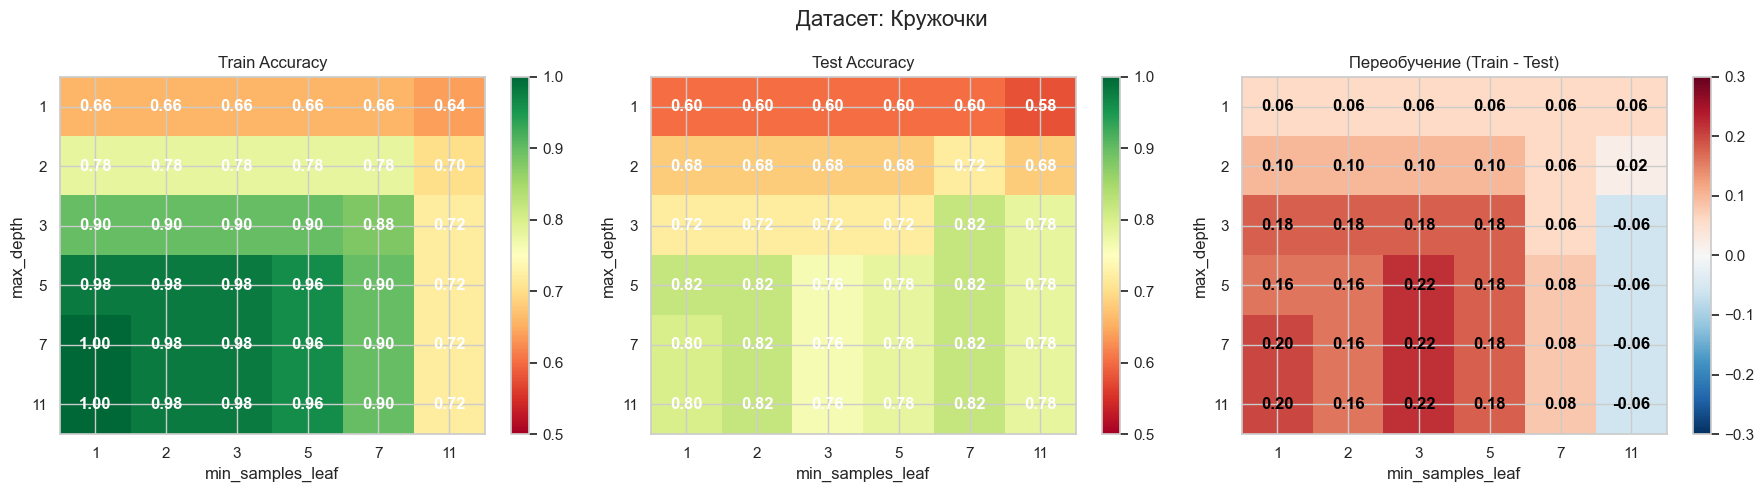

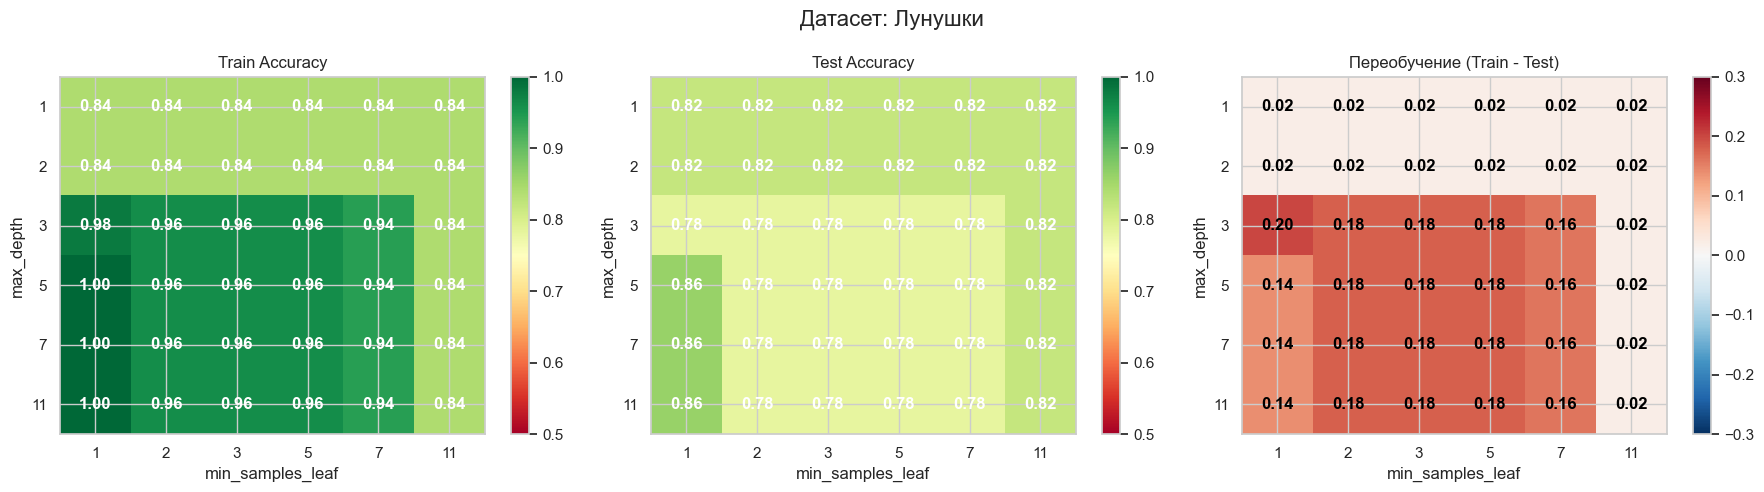

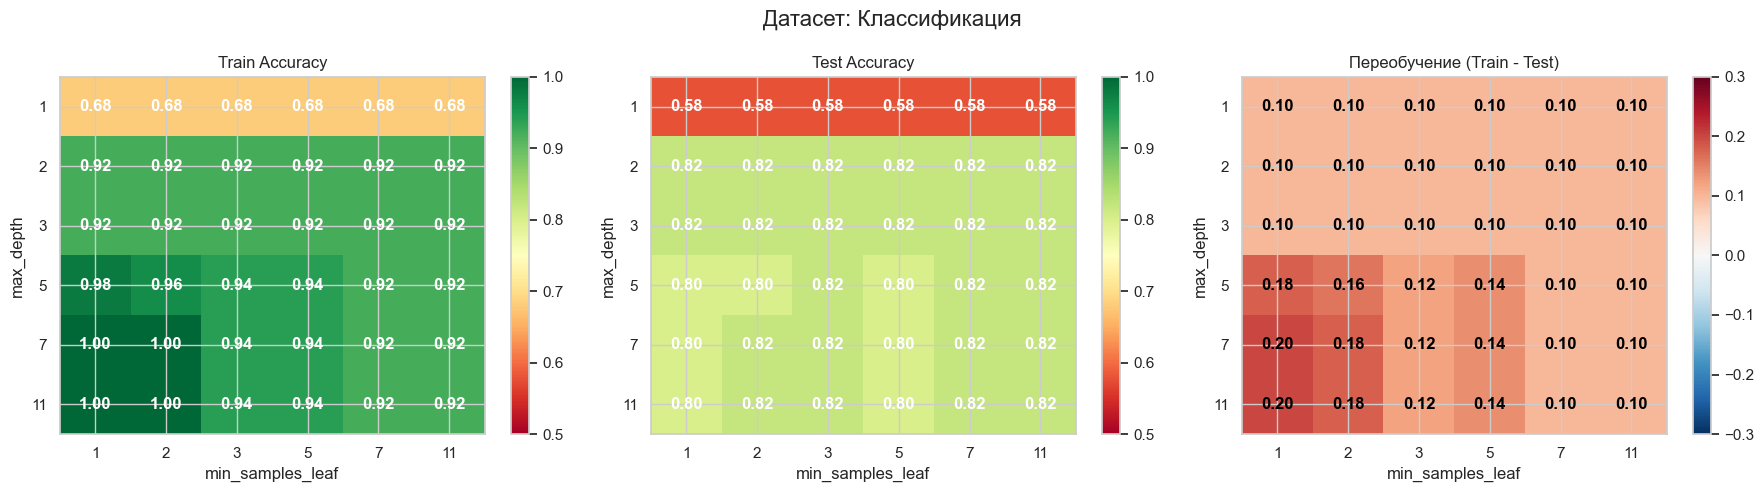

In [20]:
for name, (X, y) in datasets:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.5, stratify=y, random_state=43
    )
    
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'Датасет: {name}', fontsize=16)
    
    train_matrix = np.zeros((len(params['max_depth']), len(params['min_samples_leaf'])))
    test_matrix = np.zeros((len(params['max_depth']), len(params['min_samples_leaf'])))
    delta_matrix = np.zeros((len(params['max_depth']), len(params['min_samples_leaf'])))
    
    for i, max_depth in enumerate(params['max_depth']):
        for j, min_samples_leaf in enumerate(params['min_samples_leaf']):
            model = DecisionTreeClassifier(
                max_depth=max_depth,
                min_samples_leaf=min_samples_leaf,
                random_state=42
            )
            model.fit(X_train, y_train)
            
            acc_train = accuracy_score(y_train, model.predict(X_train))
            acc_test = accuracy_score(y_test, model.predict(X_test))
            
            train_matrix[i, j] = acc_train
            test_matrix[i, j] = acc_test
            delta_matrix[i, j] = acc_train - acc_test
    
    im1 = ax1.imshow(train_matrix, cmap='RdYlGn', aspect='auto', vmin=0.5, vmax=1.0)
    ax1.set_title('Train Accuracy')
    ax1.set_xlabel('min_samples_leaf')
    ax1.set_ylabel('max_depth')
    ax1.set_xticks(range(len(params['min_samples_leaf'])))
    ax1.set_yticks(range(len(params['max_depth'])))
    ax1.set_xticklabels(params['min_samples_leaf'])
    ax1.set_yticklabels(params['max_depth'])
    plt.colorbar(im1, ax=ax1)
    
    im2 = ax2.imshow(test_matrix, cmap='RdYlGn', aspect='auto', vmin=0.5, vmax=1.0)
    ax2.set_title('Test Accuracy')
    ax2.set_xlabel('min_samples_leaf')
    ax2.set_ylabel('max_depth')
    ax2.set_xticks(range(len(params['min_samples_leaf'])))
    ax2.set_yticks(range(len(params['max_depth'])))
    ax2.set_xticklabels(params['min_samples_leaf'])
    ax2.set_yticklabels(params['max_depth'])
    plt.colorbar(im2, ax=ax2)
    
    im3 = ax3.imshow(delta_matrix, cmap='RdBu_r', aspect='auto', vmin=-0.3, vmax=0.3)
    ax3.set_title('Переобучение (Train - Test)')
    ax3.set_xlabel('min_samples_leaf')
    ax3.set_ylabel('max_depth')
    ax3.set_xticks(range(len(params['min_samples_leaf'])))
    ax3.set_yticks(range(len(params['max_depth'])))
    ax3.set_xticklabels(params['min_samples_leaf'])
    ax3.set_yticklabels(params['max_depth'])
    plt.colorbar(im3, ax=ax3)
    
    for ax, matrix in zip([ax1, ax2, ax3], [train_matrix, test_matrix, delta_matrix]):
        for i in range(len(params['max_depth'])):
            for j in range(len(params['min_samples_leaf'])):
                ax.text(j, i, f'{matrix[i, j]:.2f}', 
                       ha='center', va='center', 
                       color='white' if abs(matrix[i, j]) > 0.5 else 'black',
                       fontweight='bold')
    
    plt.tight_layout()
    plt.show()

__Ответ:__   
Глубина дерева: если увеличить глубину дерева больше чем 3, то на всех трех датасетах модель начинает переобучаться — на обучающей выборке точность близка к 100%, но на тестовой становится хуже.

Количество листьев: качество модели перестает сильно улучшаться после 5 листьев, возможно, потому что дальше дерево либо не находит полезных разбиений, либо переобучается на шуме. На датасете "Лунушки (moon)" даже сильное падение качества при глубине 3, это связано с особенностями самой выборки.

Для датасета "Классификация" деревья отработали практически отлично (кроме глубины 1).

В общем, большая глубина не всегда приводит к лучшим результатам, как и количество листьев

# 2. Решающие деревья своими руками

В этой части вам нужно реализовать свой класс для обучения решающего дерева в задаче бинарной классификации с возможностью обработки вещественных и категориальных признаков.

__Задание 3. (1.5 балл)__

Реализуйте функцию find_best_split из модуля hw2code.py

__Задание 4. (0.5 балла)__

Загрузите таблицу students.csv (это немного преобразованный датасет [User Knowledge](https://archive.ics.uci.edu/ml/datasets/User+Knowledge+Modeling)). В ней признаки объекта записаны в первых пяти столбцах, а в последнем записана целевая переменная (класс: 0 или 1). Постройте на одном изображении пять кривых "порог — значение критерия Джини" для всех пяти признаков. Отдельно визуализируйте scatter-графики "значение признака — класс" для всех пяти признаков.

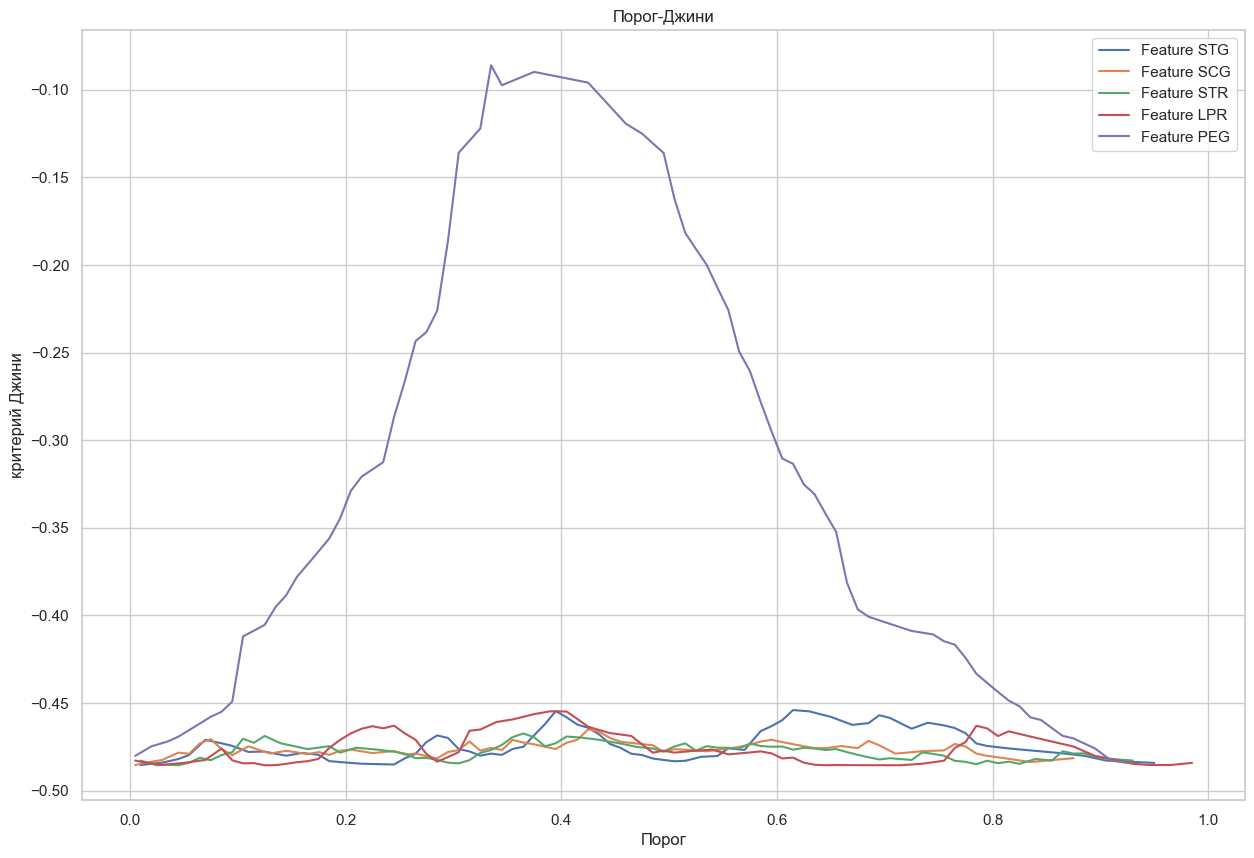

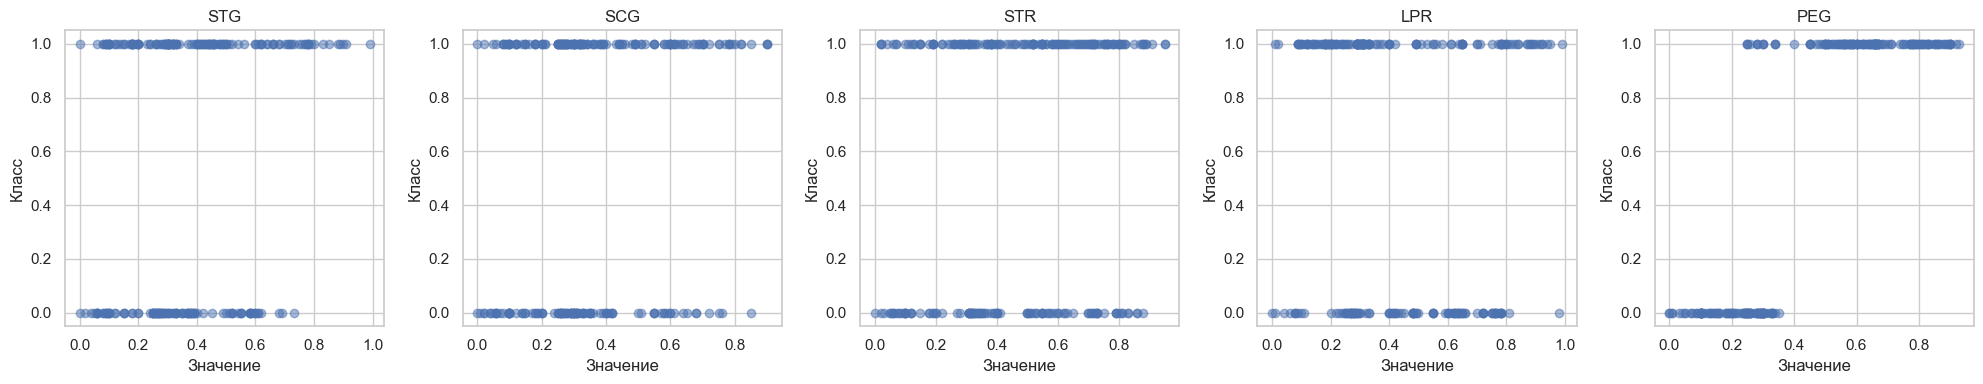

In [21]:
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
from hw2code import find_best_split

df = pd.read_csv("./datasets/students.csv")
df.head()
df.describe()

X = df.iloc[:, :-1]
y = df.iloc[:, -1].values

plt.figure(figsize=(15, 10))

for i, column in enumerate(X.columns):
    thresholds, ginis, _, _ = find_best_split(X[column].values, y)
    plt.plot(thresholds, ginis, label=f'Feature {column}')

plt.title("Порог-Джини")
plt.xlabel("Порог")
plt.ylabel("критерий Джини")
plt.legend()
plt.grid(True)
plt.show()

fig, axs = plt.subplots(1, 5, figsize=(20, 4))
for i, column in enumerate(X.columns):
    axs[i].scatter(X[column], y, alpha=0.5)
    axs[i].set_title(f'{column}')
    axs[i].set_xlabel("Значение")
    axs[i].set_ylabel("Класс")

plt.tight_layout()
plt.show()

__Задание 5. (0.5 балла)__

Исходя из кривых значений критерия Джини, по какому признаку нужно производить деление выборки на два поддерева? Согласуется ли этот результат с визуальной оценкой scatter-графиков? Как бы охарактеризовали вид кривой для "хороших" признаков, по которым выборка делится почти идеально? Чем отличаются кривые для признаков, по которым деление практически невозможно?

**Ответ:** PEG подходит лучше для деления выборки - это видно и по точкам scatter-графиков (они идеально делятся на две части примерно в 0.4), так и на гкривых значениях Джини в этой же точке график PEG показывает наилучший результат(максимум). Хорошие графики кривых напоминают нормальное распределение, а плохие - являются просто ломанной, не имеющих явного максимума (больше плоская) 

__Задание 6. (1.5 балла).__

Разберитесь с уже написанным кодом в классе DecisionTree модуля hw2code.py. Найдите ошибки в реализации метода \_fit_node. Напишите функцию \_predict_node.

 Построение дерева осуществляется согласно базовому жадному алгоритму, предложенному в лекции. Выбор лучшего разбиения необходимо производить по критерию Джини. Критерий останова: все объекты в листе относятся к одному классу или ни по одному признаку нельзя разбить выборку. Ответ в листе: наиболее часто встречающийся класс в листе. Для категориальных признаков выполняется преобразование, описанное в лекции в разделе «Учет категориальных признаков».

__Задание 7. (0.5 балла)__

Протестируйте свое решающее дерево на датасете [mushrooms](https://archive.ics.uci.edu/ml/datasets/Mushroom). Вам нужно скачать таблицу agaricus-lepiota.data (лежит на гитхабе вместе с заданием), прочитать ее с помощью pandas, применить к каждому столбцу LabelEncoder (из sklearn), чтобы преобразовать строковые имена категорий в натуральные числа. Первый столбец — это целевая переменная (e — edible, p — poisonous) Мы будем измерять качество с помощью accuracy, так что нам не очень важно, что будет классом 1, а что — классом 0. Обучите решающее дерево на половине случайно выбранных объектов (признаки в датасете категориальные) и сделайте предсказания для оставшейся половины. Вычислите accuracy.

У вас должно получиться значение accuracy, равное единице (или очень близкое к единице), и не очень глубокое дерево.

In [22]:
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from hw2code import DecisionTree

df = pd.read_csv("./datasets/agaricus-lepiota.data", header=None)

encoders = {}
for col in df.columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

y = df.iloc[:, 0].values
X = df.iloc[:, 1:].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, stratify=y, random_state=42)

feature_types = ["categorical"] * X.shape[1]
tree = DecisionTree(feature_types)
tree.fit(X_train, y_train)

y_pred = tree.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f"Accuracy  mushrooms: {acc:.3f}")

def tree_depth(node):
    if node["type"] == "terminal":
        return 0
    left_depth  = tree_depth(node["left_child"])
    right_depth = tree_depth(node["right_child"])
    return 1 + max(left_depth, right_depth)

depth = tree_depth(tree._tree)
print(f"Depth: {depth}")

Accuracy  mushrooms: 1.000
Depth: 6


__Задание 8. (бонус, 1 балл)__

Реализуйте в классе DecisionTree поддержку параметров max_depth, min_samples_split и min_samples_leaf по аналогии с DecisionTreeClassifier. Постройте графики зависимости качества предсказания в зависимости от этих параметров для набора данных tic-tac-toe (см. следующий пункт).

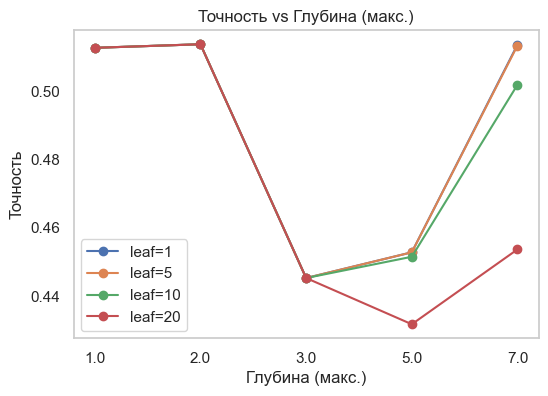

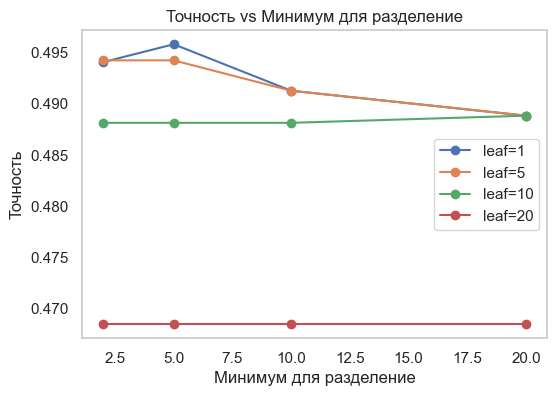

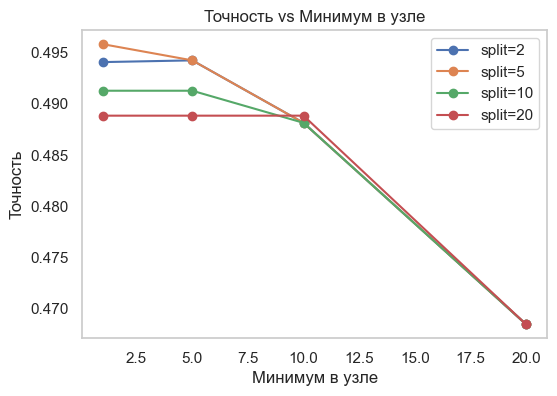

In [23]:
from sklearn.model_selection import cross_val_score


df = pd.read_csv("datasets/tic-tac-toe-endgame.csv")

X = df.iloc[:, :-1]
y = df.iloc[:, -1]


X = X.apply(LabelEncoder().fit_transform)

enc = LabelEncoder()
y = enc.fit_transform(y)

params = {
    'max_depth':       [None, 1, 2, 3, 5, 7],
    'min_samples_split':[2, 5, 10, 20],
    'min_samples_leaf': [1, 5, 10, 20]
}

results = []

for md in params['max_depth']:
    for mss in params['min_samples_split']:
        for msl in params['min_samples_leaf']:
            tree = DecisionTree(feature_types,
                                max_depth=md,
                                min_samples_split=mss,
                                min_samples_leaf=msl)
            scores = cross_val_score(
                tree,
                X.values,
                y,
                cv=5,
                scoring='accuracy'
            )
            results.append({
                'max_depth': md,
                'min_samples_split': mss,
                'min_samples_leaf': msl,
                'accuracy_mean': scores.mean()
            })

res = pd.DataFrame(results)
plt.figure(figsize=(6,4))
for msl in [1, 5, 10, 20]:
    sub = res[res['min_samples_leaf']==msl]
    means = sub.groupby('max_depth')['accuracy_mean'].mean()
    plt.plot(means.index.astype(str), means.values, marker='o', label=f"leaf={msl}")
plt.xlabel("Глубина (макс.)")
plt.ylabel("Точность")
plt.legend()
plt.title("Точность vs Глубина (макс.)")
plt.grid()
plt.show()

plt.figure(figsize=(6,4))
for msl in [1, 5, 10, 20]:
    sub = res[res['min_samples_leaf']==msl]
    means = sub.groupby('min_samples_split')['accuracy_mean'].mean()
    plt.plot(means.index, means.values, marker='o', label=f"leaf={msl}")
plt.xlabel("Минимум для разделение")
plt.ylabel("Точность")
plt.legend()
plt.title("Точность vs Минимум для разделение")
plt.grid()
plt.show()

plt.figure(figsize=(6,4))
for mss in [2, 5, 10, 20]:
    sub = res[res['min_samples_split']==mss]
    means = sub.groupby('min_samples_leaf')['accuracy_mean'].mean()
    plt.plot(means.index, means.values, marker='o', label=f"split={mss}")
plt.xlabel("Минимум в узле")
plt.ylabel("Точность")
plt.legend()
plt.title("Точность vs Минимум в узле")
plt.grid()
plt.show()

__Задание 9. (2 балла)__

Загрузите следующие наборы данных (напомним, что pandas умеет загружать файлы по url, в нашем случае это файл \*.data), предварительно ознакомившись с описанием признаков и целевой переменной в каждом из них (она записаны в Data Folder, в файле *.names): 
* [mushrooms](https://archive.ics.uci.edu/ml/datasets/Mushroom) (загрузили в предыдущем пункте, классы записаны в нулевом столбце)
* [tic-tac-toe](https://archive.ics.uci.edu/ml/datasets/Tic-Tac-Toe+Endgame) (классы записаны в последнем столбце, датасет лежит на гитхабе вместе с заданием)
* [cars](https://archive.ics.uci.edu/ml/datasets/Car+Evaluation) (классы записаны в последнем столбце, считаем что unacc, acc — это класс 0, good, vgood — класс 1)
* [nursery](https://archive.ics.uci.edu/ml/datasets/Nursery) (классы записаны в последнем столбце, считаем, что not_recom и recommend — класс 0, very_recom, priority, spec_prior — класс 1).

Закодируйте категориальные признаки, использовав LabelEncoder. С помощью cross_val_score (cv=10) оцените accuracy на каждом из этих наборов данных следующих алгоритмов:
* DecisionTree, считающий все признаки вещественными
* DecisionTree, считающий все признаки категориальными
* DecisionTree, считающий все признаки вещественными + one-hot-encoding всех признаков
* DecisionTreeClassifier из sklearn. Запишите результат в pd.DataFrame (по строкам — наборы данных, по столбцам — алгоритмы).

Рекомендации:
* Чтобы cross_val_score вычисляла точность, нужно передать scoring=make_scorer(accuracy_score), обе фукнции из sklearn.metrics.
* Если вам позволяет память (а она скорее всего позволяет), указывайте параметр sparse=False в OneHotEncoder (если вы, конечно, используете его). Иначе вам придется добиваться того, чтобы ваша реализация дерева умела работать с разреженными матрицами (что тоже, в целом, не очень сложно).

In [ ]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, make_scorer
from sklearn.tree import DecisionTreeClassifier
from hw2code import DecisionTree

data = {}

# ================ ГРИБОЧКИ ================
df = pd.read_csv("./datasets/agaricus-lepiota.data", header=None)
print(df.head())
print(df.describe())
for col in df.columns:
    df[col] = LabelEncoder().fit_transform(df[col])
X = df.iloc[:, 1:].valuesmin_samples_leaf
y = df.iloc[:, 0].values
data["mushrooms"] = (X, y)

print('========================')
# ================ КРЕСТИКИ ================
df = pd.read_csv("./datasets/tic-tac-toe-endgame.csv", header=None)
print(df.head())
print(df.describe())
X = df.iloc[:, :-1].apply(LabelEncoder().fit_transform).values
y = LabelEncoder().fit_transform(df.iloc[:, -1].values)
data["tic-tac-toe"] = (X, y)

print('========================')
# ================ МАШИНКИ ================
cols = ["buying", "maint", "doors", "persons", "lug_boot", "safety", "class"]
df = pd.read_csv(
    "https://archive.ics.uci.edu/ml/machine-learning-databases/car/car.data", names=cols
)
print(df.head())
print(df.describe())
df["class"] = df["class"].map(lambda v: 0 if v in ("unacc", "acc") else 1)
X = df.iloc[:, :-1].apply(LabelEncoder().fit_transform).values
y = df["class"].values
data["cars"] = (X, y)

print('========================')
# ================ КАКИЕ_ТО ДЕТСКИЕ ================
cols = [
    "parents",
    "has_nurs",
    "form",
    "children",
    "housing",
    "finance",
    "social",
    "health",
    "class",
]
df = pd.read_csv(
    "https://archive.ics.uci.edu/ml/machine-learning-databases/nursery/nursery.data",
    names=cols,
)
print(df.head())
print(df.describe())
df["class"] = df["class"].map(lambda v: 0 if v in ("not_recom", "recommend") else 1)
X = df.iloc[:, :-1].apply(LabelEncoder().fit_transform).values
y = df["class"].values
data["nursery"] = (X, y)


  0  1  2  3  4  5  6  7  8  9   ... 13 14 15 16 17 18 19 20 21 22
0  p  x  s  n  t  p  f  c  n  k  ...  s  w  w  p  w  o  p  k  s  u
1  e  x  s  y  t  a  f  c  b  k  ...  s  w  w  p  w  o  p  n  n  g
2  e  b  s  w  t  l  f  c  b  n  ...  s  w  w  p  w  o  p  n  n  m
3  p  x  y  w  t  p  f  c  n  n  ...  s  w  w  p  w  o  p  k  s  u
4  e  x  s  g  f  n  f  w  b  k  ...  s  w  w  p  w  o  e  n  a  g

[5 rows x 23 columns]
          0     1     2     3     4     5     6     7     8     9   ...    13  \
count   8124  8124  8124  8124  8124  8124  8124  8124  8124  8124  ...  8124   
unique     2     6     4    10     2     9     2     2     2    12  ...     4   
top        e     x     y     n     f     n     f     c     b     b  ...     s   
freq    4208  3656  3244  2284  4748  3528  7914  6812  5612  1728  ...  4936   

          14    15    16    17    18    19    20    21    22  
count   8124  8124  8124  8124  8124  8124  8124  8124  8124  
unique     9     9     1     4     3     5 

In [ ]:
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
scorer = make_scorer(accuracy_score)

def make_algorithms(X):
    n_feat = X.shape[1]
    algos = {
        "real": DecisionTree(["real"] * n_feat),
        "categorical": DecisionTree(["categorical"] * n_feat),
        "DecisionTreeClassifier": DecisionTreeClassifier(random_state=42),
    }
    ohe = OneHotEncoder(sparse_output=False)
    X_ohe = ohe.fit_transform(X)
    algos["real_OHE"] = DecisionTree(["real"] * X_ohe.shape[1])
    return algos, X_ohe


res = []
for name, (X, y) in data.items():
    algos, X_ohe = make_algorithms(X)
    for alg_name, alg in algos.items():
        X_use = X_ohe if alg_name == "real_OHE" else X
        scores = cross_val_score(alg, X_use, y, cv=10, scoring=scorer)
        res.append(
            {
                "dataset": name,
                "algorithm": alg_name,
                "accuracy": scores.mean(),
            }
        )

df_res = pd.DataFrame(res)

table = df_res.pivot_table(
    index="dataset", columns="algorithm", values="accuracy"
).round(3)

print(table)

algorithm    DecisionTreeClassifier  categorical   real  real_OHE
dataset                                                          
cars                          0.943        0.968  0.943     0.919
mushrooms                     0.960        1.000  0.999     1.000
nursery                       1.000        1.000  1.000     1.000
tic-tac-toe                   0.785        0.609  0.497     0.595


__Задание 10. (1 балла)__

Проанализируйте результаты эксперимента. 
Одинаково ли для разных наборов данных ранжируются алгоритмы? 
Порассуждайте, почему так происходит. 

Обратите внимание на значение признаков в разных наборах данных. 
Присутствует ли в результатах какая-то компонента случайности? 
Можно ли повлиять на нее и улушить работу алгоритмов?

**Ответ:**  
на разных наборах данных разные показатели - наилучшие в mushrooms и nursery. В tic-tac-toe - наихудшие показатели (кроме стандартного дерево из sklearn)

Жадные деревье лучше работают с категориальными признаками (поэтому musrooms/nursery и выигрывают) 

Для cars лучше всего такде работают категориальные признаки.

tic-tac-toe -  там сетка, возможно ее очень сложно и непонятно интерпретировать и потому дерево обучается плохо

Также в результатах присутствует компонента случайности из-за кросс-валидации. Улучшить её можно при помощи увеличения cv (это влияет на дисперсию) или попробовав зафиксировать random_state. На алгоритмы влияют гиперпараметры - max_depth, min_samples_split и min_samples_leaf.

Вставьте что угодно, описывающее ваши впечатления от этого задания:

![Впечатление](https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQAFhmZ3ACJHY--Xhl5oWsi92a1PEl1_YYfvw&s)